In [2]:
import pandas as pd
import numpy as np
from itertools import combinations
import networkx as nx
import os
import warnings
import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import squarify
import math
import seaborn as sns
from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
import shap
import copy
from sklearn.metrics import mean_squared_error
from tqdm.notebook import tqdm
from sklearn.base import clone

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import numpy as np



In [6]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from sklearn.svm import SVR

def TuneRegressor(regressor, X, Y):
    if regressor == "svr":
        model = SVR()
        param_distributions = {
            'kernel': ['linear','poly'],
            'C': [0.1, 1, 10, 100]
        }

    elif regressor == "xgbr":
        model = xgb.XGBRegressor()
        param_distributions = {
            'n_estimators': randint(50, 200),
            'max_depth': randint(3, 10),
            'learning_rate': uniform(0.01, 0.3),
        }

    random_search = RandomizedSearchCV(
        model,
        param_distributions=param_distributions,
        n_iter=3,
        scoring='neg_mean_squared_error',
        cv=5,
        verbose=0
    )

    random_search.fit(X, Y)
    return random_search.best_estimator_


In [3]:
data = pd.read_csv(r"D:\论文数据\2025.2 出口选择\20190519+问卷统计表.csv", encoding='utf-8') 
data = data.drop('序号', axis=1)
#data
rename_dict = {
    '性别': 'GE',  ##
    '年龄段': 'AG',  ## 
    '教育程度': 'ED',  ##
    '行动能力': 'MO',  ##
    '您乘坐客船的经历（不含本次）': 'PE',  ##
    '与您一起出行的人员数量': 'GS',  ##
    '接受船舶疏散教育/训练的经历': 'ET',  ##                     
    '听到疏散逃生警报，您会等待工作人员确认后再行动': 'AM1',
    '听到疏散逃生警报，您会立即疏散逃生': 'AM2',
    '听到疏散逃生警报，您会观察其他人的动静再行动': 'AM3',
    '假如听到疏散逃生警报，您会自行开门查看确认': 'AM4',      
    '疏散逃生时，您会选择距离最近的出口': 'EC1',  #
    '疏散逃生时，您会选择最熟悉的出口': 'EC2',  #
    '疏散逃生时，您会选择跟着大多数人走': 'EC3',  #
    '疏散逃生时，您会选择听从疏散指示或广播': 'EC4',  #       
    '您会耐心排队等待': 'CO1',
    '您会自行寻找其他出口': 'CO2',  
    '您会往前挤行': 'CO3',
    '您会听从船员引导': 'CO4',
    '贵重物品遗留，您是否会返回寻找': 'RT1',
    '家人遗留，您是否会返回寻找': 'RT2',
    '疏散过程中，您是否会协助他人进行疏散': 'CC1',
    '疏散过程中，您是否会超越他人或向前挤行': 'CC2',
    '疏散逃生时，您是否会寻找同伴一起逃生': 'FC',
    '假如发生火灾，您是否会出现恐慌心理': 'EP',
    '疏散时，您是否会携带大件行李箱': 'CL',
    '疏散时，您是否会跟从团队中的临时领导者': 'FL'
}
data.rename(columns=rename_dict, inplace=True)
df = data
'''
df = data
df_ec = df.drop(columns=['NE', 'FE', 'FM', 'FI'])
df_ne = df.drop(columns=['FE', 'FM', 'FI'])
df_fe = df.drop(columns=['NE', 'FM', 'FI'])
df_fm = df.drop(columns=['NE', 'FE', 'FI'])
df_fi = df.drop(columns=['NE', 'FE', 'FM'])
'''

"\ndf = data\ndf_ec = df.drop(columns=['NE', 'FE', 'FM', 'FI'])\ndf_ne = df.drop(columns=['FE', 'FM', 'FI'])\ndf_fe = df.drop(columns=['NE', 'FM', 'FI'])\ndf_fm = df.drop(columns=['NE', 'FE', 'FI'])\ndf_fi = df.drop(columns=['NE', 'FE', 'FM'])\n"

In [41]:
# =======================
# 数据预处理
# =======================
# 前部变量（行为与心理因素）
front_vars = ['GE', 'AG', 'ED', 'MO', 'PE', 'GS', 'ET', 'AM1', 'AM2', 'AM3', 'AM4', 
              'CO1', 'CO2', 'CO3', 'CO4', 'RT1', 'RT2', 'CC1', 'CC2', 'FC', 'EP', 'CL', 'FL']

# 后部变量（出口选择行为）
exit_vars = ['EC1', 'EC2', 'EC3', 'EC4']

In [42]:
# 控制变量
Control_vars = ['GE', 'AG', 'ED', 'MO', 'PE', 'GS', 'ET']

# 处理变量
Treatment_vars = ['AM1', 'AM2', 'AM3', 'AM4', 'CO1', 'CO2', 'CO3', 'CO4', 'RT1', 'RT2', 'CC1', 'CC2', 'FC', 'EP', 'CL', 'FL']

# 结果变量（出口选择行为）

Outcome_vars1 = ['EC1']
Outcome_vars2 = ['EC2']
Outcome_vars3 = ['EC3']
Outcome_vars4 = ['EC4']

In [71]:
# ======================
# 提取变量
# ======================
all_vars= Treatment_vars+ Control_vars

X = df[all_vars]
y = df[exit_vars]
y1 = df[Outcome_vars1[0]]
y2 = df[Outcome_vars2[0]]
y3 = df[Outcome_vars3[0]]
y4 = df[Outcome_vars4[0]]

# ======================
# 划分训练集与测试集
# ======================
X_train, X_test, y_train1, y_test1 = train_test_split(
    X, y1, test_size=0.2, random_state=42
)

# 其他三个结果变量基于同样的索引切分
# 以保证 4 个任务拥有完全一致的训练/测试样本

y_train2 = y2.loc[X_train.index]
y_test2  = y2.loc[X_test.index]

y_train3 = y3.loc[X_train.index]
y_test3  = y3.loc[X_test.index]

y_train4 = y4.loc[X_train.index]
y_test4  = y4.loc[X_test.index]


# 负相关学习

In [72]:
from sklearn.linear_model import Lasso, ElasticNet, OrthogonalMatchingPursuit
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.neural_network import MLPRegressor

In [205]:
# === 自定义模型：Locally Weighted Regression（LWR）===
class LocallyWeightedRegression:
    def __init__(self, tau=0.5):
        self.tau = tau

    def fit(self, X, y):
        self.X = X
        self.y = y
        return self

    def predict(self, X_test):
        preds = []
        for x in X_test:
            w = np.exp(-np.sum((self.X - x)**2, axis=1) / (2 * self.tau**2))
            W = np.diag(w)
            try:
                theta = np.linalg.inv(self.X.T @ W @ self.X) @ self.X.T @ W @ self.y
                preds.append(x @ theta)
            except:
                preds.append(np.average(self.y, weights=w))
        return np.array(preds)

# === 自定义模型：Residual FC Network（带残差结构）===
class ResidualFCN:
    def __init__(self, hidden=64, epochs=200, lr=0.001):
        self.hidden = hidden
        self.epochs = epochs
        self.lr = lr

    def fit(self, X, y):
        self.model = MLPRegressor(
            hidden_layer_sizes=(self.hidden, self.hidden),
            max_iter=self.epochs,
            learning_rate_init=self.lr
        )
        self.model.fit(X, y)
        return self

    def predict(self, X):
        return self.model.predict(X)


# === 自定义模型：BP Neural Network（MLP 等价替代）===
class BPNeuralNetwork(MLPRegressor):
    pass

In [206]:
# ==========================================================
# ⭐ Final Model Pool with Small Hyperparameter Ranges ⭐
# ==========================================================

models = {

    # ------------------------------------------------------
    # 1. Linear Models
    # ------------------------------------------------------
    "LinearRegression": (
        LinearRegression(),
        {}
    ),


    "OMP": (
        OrthogonalMatchingPursuit(),
        {"n_nonzero_coefs": [None, 5, 10]}
    ),


    # ------------------------------------------------------
    # 2. Kernel-based Models
    # ------------------------------------------------------
    "SVR": (
        SVR(),
        {
            "C": [1, 5, 10],
            "epsilon": [0.05, 0.1],
            "kernel": ["rbf"]
        }
    ),

    "KernelRidge": (
        KernelRidge(),
        {
            "alpha": [0.1, 1.0],
            "kernel": ["rbf"],
            "gamma": [0.01, 0.1]
        }
    ),


    # ------------------------------------------------------
    # 3. Distance-based Models
    # ------------------------------------------------------
    "KNN": (
        KNeighborsRegressor(),
        {
            "n_neighbors": [5, 7, 9],
            "weights": ["uniform", "distance"]
        }
    ),


    # Locally Weighted Regression (自定义版本)
    "LWR": (
        LocallyWeightedRegression(),
        {"tau": [0.3, 0.5, 0.8]}
    ),


    # ------------------------------------------------------
    # 4. Tree-based Models
    # ------------------------------------------------------

    "RandomForest": (
        RandomForestRegressor(),
        {
            "n_estimators": [200, 300],
            "max_depth": [None, 10],
            "max_features": ["sqrt"]
        }
    ),

    "ExtraTrees": (
        ExtraTreesRegressor(),
        {
            "n_estimators": [200, 300],
            "max_depth": [None, 10]
        }
    ),


    # ------------------------------------------------------
    # 5. Boosting Models
    # ------------------------------------------------------
    "GBDT": (
        GradientBoostingRegressor(),
        {
            "n_estimators": [200, 300],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5]
        }
    ),

    "XGB": (
        XGBRegressor(),
        {
            "n_estimators": [200, 300],
            "max_depth": [4, 6],
            "learning_rate": [0.05, 0.1],
            "subsample": [0.8],
            "colsample_bytree": [0.8]
        }
    ),

    "LGBM": (
        LGBMRegressor(),
        {
            "n_estimators": [200, 400],
            "num_leaves": [31, 63],
            "learning_rate": [0.05],
            "subsample": [0.8]
        }
    ),


    # ------------------------------------------------------
    # 6. Neural Network Models
    # ------------------------------------------------------
    "MLP": (
        MLPRegressor(max_iter=500),
        {
            "hidden_layer_sizes": [(64,), (128, 64)],
            "learning_rate_init": [0.001, 0.01]
        }
    ),

    "BP": (
        BPNeuralNetwork(max_iter=500),
        {
            "hidden_layer_sizes": [(64,), (128,)],
            "learning_rate_init": [0.001, 0.01]
        }
    ),

    "ResFCN": (
        ResidualFCN(),
        {
            "hidden": [32, 64],
            "epochs": [200],
            "lr": [0.001, 0.005]
        }
    )
}


In [207]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y2, test_size=0.2, random_state=42
)


In [208]:
predictions = {}
rmse_dict = {}

for name, (model, params) in models.items():    # 解包 (model, params)
    try:
        print(f"Training {name} ...")

        # 复制模型（防止影响原对象）
        import copy
        mdl = copy.deepcopy(model)

        # 训练
        mdl.fit(X_train, y_train)

        # 预测
        pred = mdl.predict(X_test)

        # 计算 RMSE
        rmse = np.sqrt(mean_squared_error(y_test, pred))

        # 保存结果
        predictions[name] = pred
        rmse_dict[name] = rmse

        print(f"{name:20s} | RMSE = {rmse:.4f}")

    except Exception as e:
        print(f"{name:20s} ❌ FAILED: {e}")


Training LinearRegression ...
LinearRegression     | RMSE = 0.8724
Training OMP ...
OMP                  | RMSE = 0.8861
Training SVR ...
SVR                  | RMSE = 0.8260
Training KernelRidge ...
KernelRidge          | RMSE = 0.8762
Training KNN ...
KNN                  | RMSE = 0.8395
Training LWR ...
LWR                  ❌ FAILED: ufunc 'subtract' did not contain a loop with signature matching types (dtype('int64'), dtype('<U3')) -> None
Training RandomForest ...
RandomForest         | RMSE = 0.8104
Training ExtraTrees ...
ExtraTrees           | RMSE = 0.7946
Training GBDT ...
GBDT                 | RMSE = 0.8154
Training XGB ...
XGB                  | RMSE = 0.8408
Training LGBM ...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 134
[LightGBM] [Info] Number of data points in the train set: 1104, number of used features: 23
[LightGBM] [In

D:\conda\envs\tf2\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP                  | RMSE = 0.8905
Training BP ...
BP                   | RMSE = 0.8796
Training ResFCN ...
ResFCN               | RMSE = 0.8818


D:\conda\envs\tf2\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [209]:
def diversity(p1, p2):
    return np.mean((p1 - p2) ** 2)


In [210]:
model_names = list(predictions.keys())
n = len(model_names)

div_matrix = pd.DataFrame(
    np.zeros((n, n)),
    index=model_names,
    columns=model_names
)

for i in range(n):
    for j in range(n):
        div_matrix.iloc[i, j] = diversity(
            predictions[model_names[i]],
            predictions[model_names[j]]
        )


In [211]:
avg_diversity = div_matrix.mean(axis=1).to_dict()


In [212]:
results = pd.DataFrame({
    "Model": model_names,
    "RMSE": [rmse_dict[m] for m in model_names],
    "Avg_Diversity": [avg_diversity[m] for m in model_names]
})

results = results.sort_values(by=["RMSE", "Avg_Diversity"], ascending=[True, False])
print("\n=== Final Model Ranking (RMSE + Diversity) ===")
print(results)



=== Final Model Ranking (RMSE + Diversity) ===
               Model      RMSE  Avg_Diversity
6         ExtraTrees  0.794610       0.164445
5       RandomForest  0.810363       0.125411
7               GBDT  0.815397       0.125668
9               LGBM  0.820296       0.150059
2                SVR  0.825989       0.130317
4                KNN  0.839513       0.178837
8                XGB  0.840791       0.251612
0   LinearRegression  0.872373       0.155236
3        KernelRidge  0.876153       0.161721
11                BP  0.879589       0.218998
12            ResFCN  0.881753       0.242920
1                OMP  0.886120       0.187513
10               MLP  0.890525       0.233996


In [213]:
pairs = []
for i in range(n):
    for j in range(i + 1, n):
        pairs.append((model_names[i], model_names[j], div_matrix.iloc[i, j]))

pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

print("\n🔥 Top-5 多样性最高（最互补）的模型组合：")
for p in pairs_sorted[:5]:
    print(f"{p[0]:20s} - {p[1]:20s} | Diversity = {p[2]:.4f}")

print("\n❄️ Top-5 多样性最低（最相似）的模型组合：")
for p in pairs_sorted[-5:]:
    print(f"{p[0]:20s} - {p[1]:20s} | Diversity = {p[2]:.4f}")



🔥 Top-5 多样性最高（最互补）的模型组合：
OMP                  - XGB                  | Diversity = 0.3728
XGB                  - MLP                  | Diversity = 0.3678
XGB                  - ResFCN               | Diversity = 0.3573
KernelRidge          - XGB                  | Diversity = 0.3560
XGB                  - BP                   | Diversity = 0.3500

❄️ Top-5 多样性最低（最相似）的模型组合：
LinearRegression     - OMP                  | Diversity = 0.0681
RandomForest         - LGBM                 | Diversity = 0.0649
RandomForest         - GBDT                 | Diversity = 0.0623
RandomForest         - ExtraTrees           | Diversity = 0.0310
LinearRegression     - KernelRidge          | Diversity = 0.0058


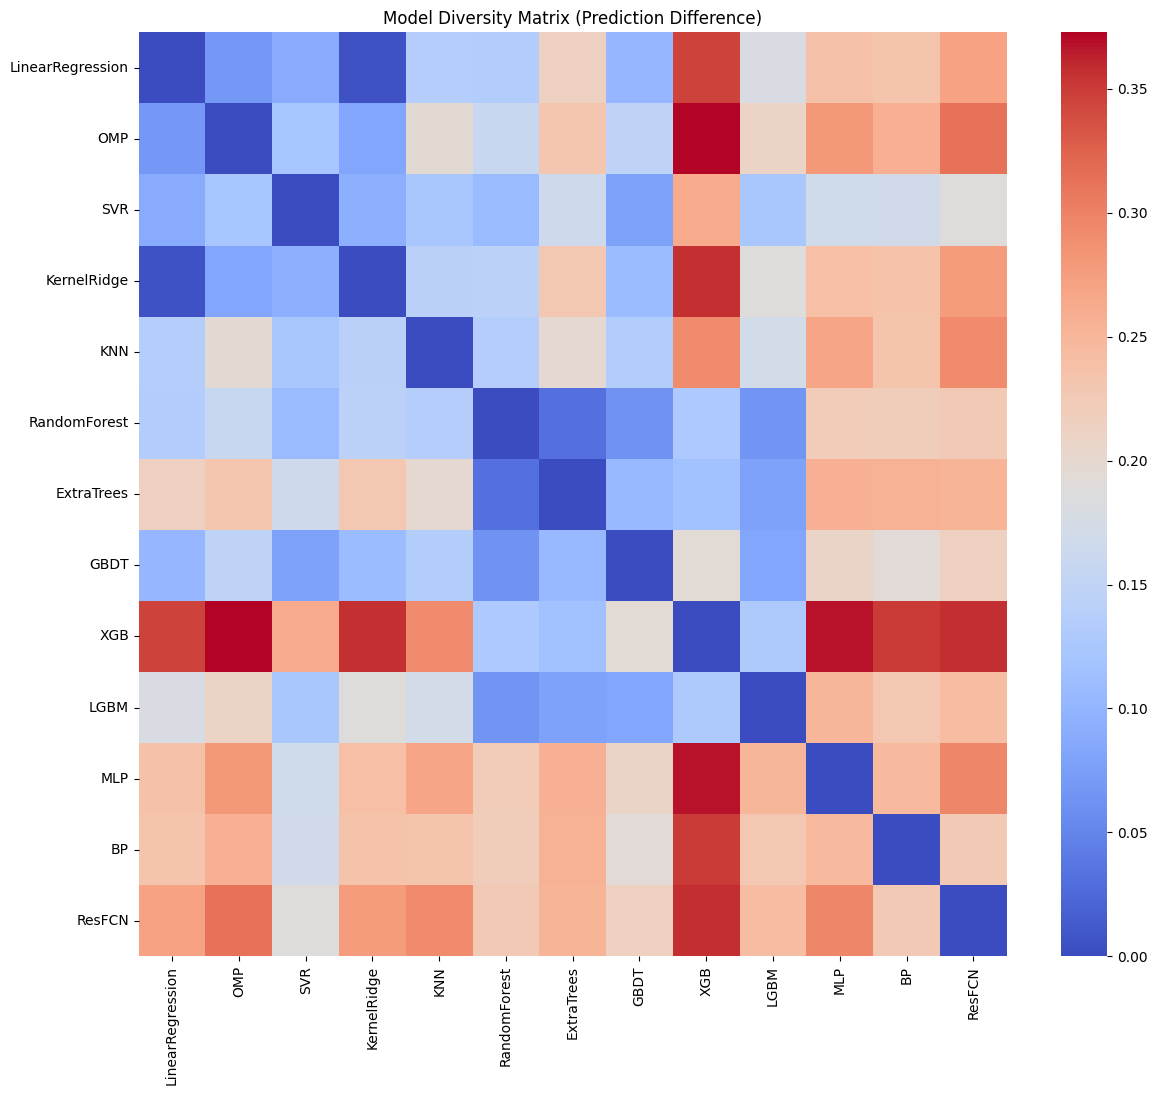

In [214]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))
sns.heatmap(div_matrix, cmap="coolwarm")
plt.title("Model Diversity Matrix (Prediction Difference)")
plt.show()


In [224]:
import numpy as np
from itertools import combinations

def stacking_rmse(lambda_a, gamma, predictions, rmse_dict, avg_diversity, y_test, model_order):
    
    selected = model_order[:gamma]  # 取前 γ 个模型

    # 计算归一化权重
    weights = []
    for m in selected:
        acc_term = 1 / (rmse_dict[m] + 1e-8)
        div_term = avg_diversity[m]
        w = (1 - lambda_a) * acc_term + lambda_a * div_term
        weights.append(w)

    weights = np.array(weights) / np.sum(weights)

    # 融合预测
    preds = np.zeros_like(y_test, dtype=float)
    for w, m in zip(weights, selected):
        preds += w * predictions[m]

    rmse = np.sqrt(np.mean((y_test - preds) ** 2))
    return rmse



In [228]:
# ========================================
# 1. 先构造 model_order（非常重要）
# ========================================
model_order = sorted(
    rmse_dict.keys(),
    key=lambda m: (rmse_dict[m], -avg_diversity[m])
)

print("Model order:", model_order)

# ========================================
# 2. 定义超细搜索范围
# ========================================
lambda_list = np.linspace(0, 1, 1000)  # ⭐ 超细：1000个lambda点
gamma_list = range(4, len(model_order))  # 至少取4个模型

best_rmse = 999
best_lambda = None
best_gamma = None

rmse_grid = {}  # (λ, γ) → RMSE

# ========================================
# 3. 网格搜索
# ========================================
for la in lambda_list:
    for g in gamma_list:
        rmse = stacking_rmse(
            lambda_a=la,
            gamma=g,
            predictions=predictions,
            rmse_dict=rmse_dict,
            avg_diversity=avg_diversity,
            y_test=y_test,
            model_order=model_order
        )

        rmse_grid[(la, g)] = rmse

        if rmse < best_rmse:
            best_rmse = rmse
            best_lambda = la
            best_gamma = g

print(f"搜索完成，共计算 {len(lambda_list)*len(gamma_list)} 个组合")

# ========================================
# 4. 输出最终最优结果
# ========================================
print("\n==============================")
print("⭐ Best Stacking Configuration")
print("==============================")
print(f"最佳 λ (权重平衡)      = {best_lambda}")
print(f"最佳 γ (模型数量)      = {best_gamma}")
print(f"最低 RMSE              = {best_rmse:.4f}")
print("==============================\n")


Model order: ['ExtraTrees', 'RandomForest', 'GBDT', 'LGBM', 'SVR', 'KNN', 'XGB', 'LinearRegression', 'KernelRidge', 'BP', 'ResFCN', 'OMP', 'MLP']
搜索完成，共计算 9000 个组合

⭐ Best Stacking Configuration
最佳 λ (权重平衡)      = 1.0
最佳 γ (模型数量)      = 7
最低 RMSE              = 0.7849



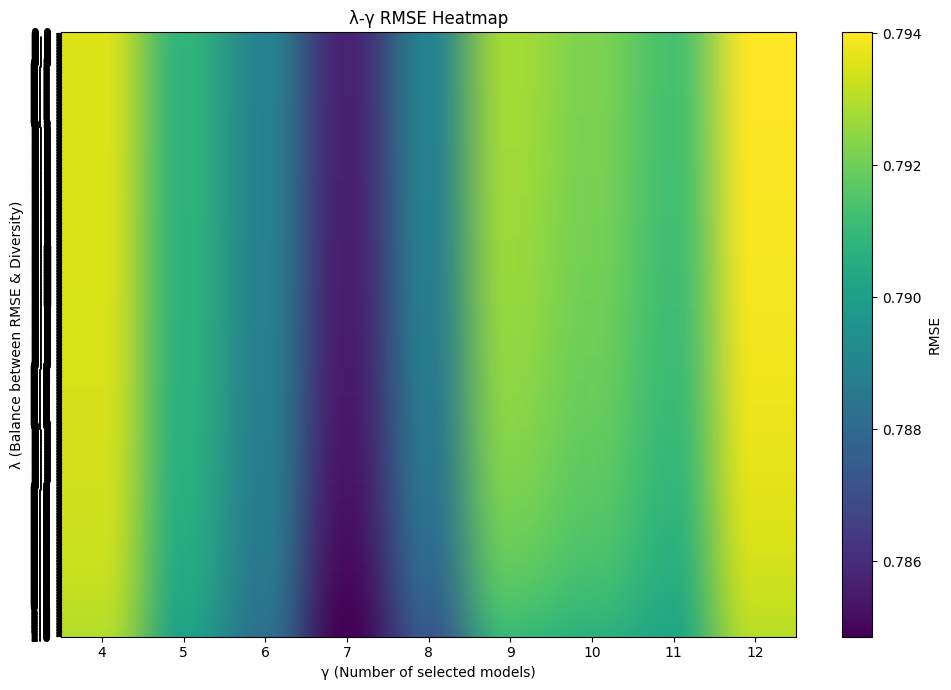

In [229]:
import numpy as np
import matplotlib.pyplot as plt

# 获取网格
lambda_vals = sorted(set([k[0] for k in rmse_grid.keys()]))
gamma_vals = sorted(set([k[1] for k in rmse_grid.keys()]))

rmse_matrix = np.zeros((len(lambda_vals), len(gamma_vals)))

for i, la in enumerate(lambda_vals):
    for j, g in enumerate(gamma_vals):
        rmse_matrix[i, j] = rmse_grid[(la, g)]

# 绘制热力图
plt.figure(figsize=(10, 7))
plt.imshow(rmse_matrix, cmap='viridis', aspect='auto')

plt.colorbar(label="RMSE")
plt.xticks(ticks=range(len(gamma_vals)), labels=gamma_vals)
plt.yticks(ticks=range(len(lambda_vals)), labels=[f"{x:.1f}" for x in lambda_vals])

plt.xlabel("γ (Number of selected models)")
plt.ylabel("λ (Balance between RMSE & Diversity)")
plt.title("λ-γ RMSE Heatmap")
plt.tight_layout()
plt.show()


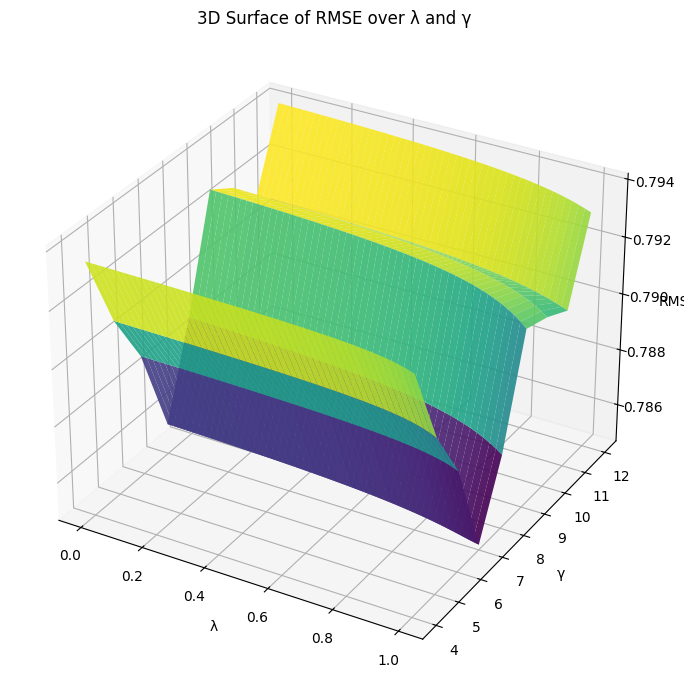

In [230]:
from mpl_toolkits.mplot3d import Axes3D

Lambda_mesh, Gamma_mesh = np.meshgrid(lambda_vals, gamma_vals, indexing='ij')

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    Lambda_mesh,
    Gamma_mesh,
    rmse_matrix,
    cmap='viridis',
    edgecolor='none',
    alpha=0.9
)

ax.set_xlabel("λ")
ax.set_ylabel("γ")
ax.set_zlabel("RMSE")
ax.set_title("3D Surface of RMSE over λ and γ")

plt.tight_layout()
plt.show()


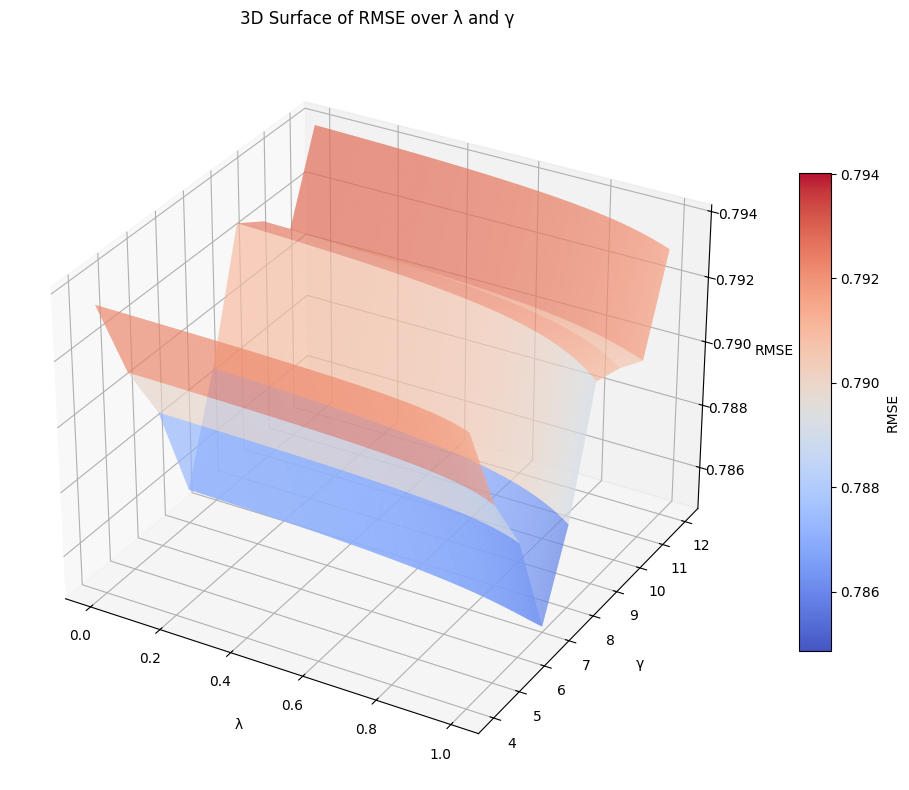

In [221]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as colors

Lambda_mesh, Gamma_mesh = np.meshgrid(lambda_vals, gamma_vals, indexing='ij')

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

# ---- 色彩归一化 + coolwarm 渐变 ----
norm = colors.Normalize(vmin=rmse_matrix.min(), vmax=rmse_matrix.max())

surf = ax.plot_surface(
    Lambda_mesh,
    Gamma_mesh,
    rmse_matrix,
    cmap='coolwarm',    # 强对比渐变色
    norm=norm,
    rstride=1,
    cstride=1,
    edgecolor='none',
    alpha=0.95
)

# ---- 加颜色条 ----
fig.colorbar(surf, ax=ax, shrink=0.65, aspect=15, label="RMSE")

# ---- 标签 + 标题 ----
ax.set_xlabel("λ", labelpad=10)
ax.set_ylabel("γ", labelpad=10)
ax.set_zlabel("RMSE", labelpad=10)
ax.set_title("3D Surface of RMSE over λ and γ", pad=15)

plt.tight_layout()
plt.show()


用于集成的模型 = ['ExtraTrees', 'RandomForest', 'GBDT', 'LGBM', 'SVR', 'KNN', 'XGB']
meta_features shape = (276, 7)
Stacking 权重 = [0.14599802 0.11134295 0.1115713  0.13322555 0.11569844 0.15877618
 0.22338756]


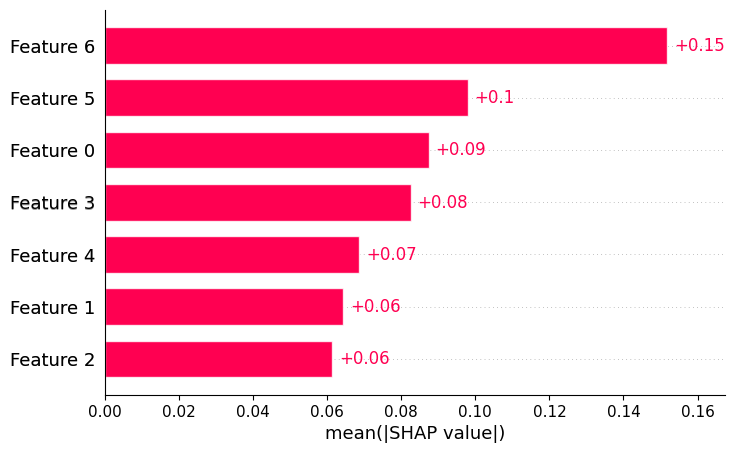

In [219]:
# 1. 选择最终模型
selected_models = model_order[:best_gamma]
print("用于集成的模型 =", selected_models)

# 2. 构造 meta-features
meta_features = np.column_stack([predictions[m] for m in selected_models])
print("meta_features shape =", meta_features.shape)

# 3. 计算 stacking 权重
def get_model_weights(best_lambda, selected_models, rmse_dict, avg_diversity):
    acc = np.array([1/(rmse_dict[m] + 1e-8) for m in selected_models])
    div = np.array([avg_diversity[m] for m in selected_models])
    raw_w = (1-best_lambda)*acc + best_lambda*div
    return raw_w / raw_w.sum()

weights = get_model_weights(best_lambda, selected_models, rmse_dict, avg_diversity)
print("Stacking 权重 =", weights)

# 4. 定义 stacking 函数（可解释）
def stacking_predict_from_meta(meta_X):
    return np.dot(meta_X, weights)

# 5. 计算模型级 SHAP
explainer = shap.Explainer(stacking_predict_from_meta, meta_features)
shap_values = explainer(meta_features)

# 6. 画模型贡献条形图
shap.plots.bar(shap_values, max_display=len(selected_models))


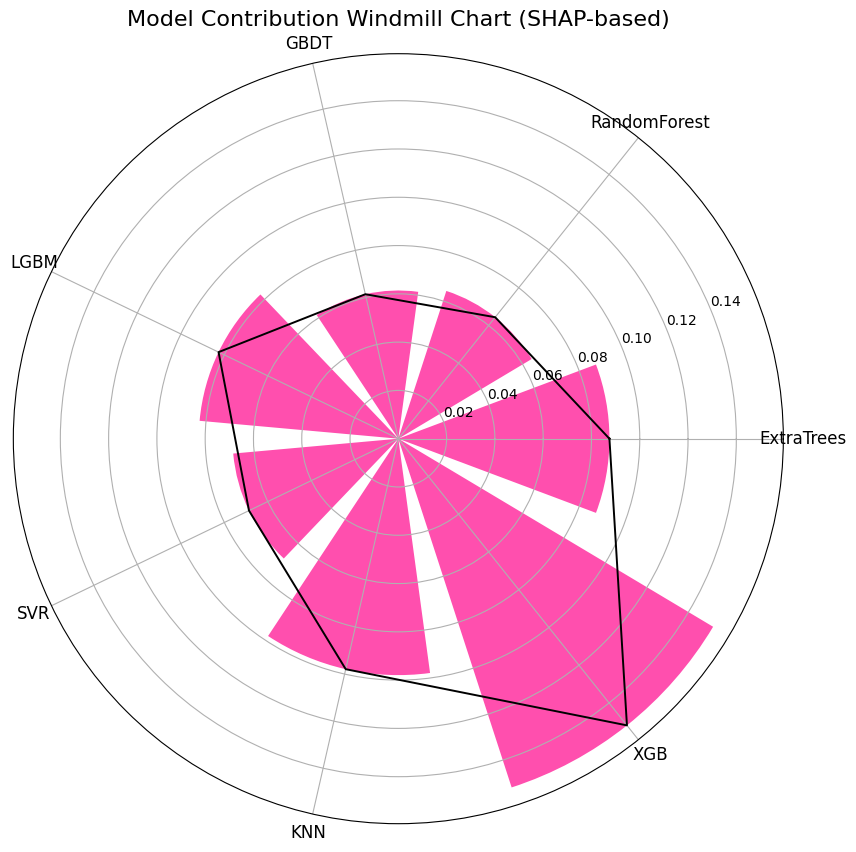

In [220]:
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# 1. 提取 SHAP 数值（兼容 list 情况）
# ===============================
if isinstance(shap_values, list):
    shap_arr = shap_values[0].values
else:
    shap_arr = shap_values.values

importance = np.abs(shap_arr).mean(axis=0)

# ===============================
# 2. 极坐标风车图
# ===============================
labels = selected_models
num_models = len(labels)

angles = np.linspace(0, 2*np.pi, num_models, endpoint=False).tolist()
angles += angles[:1]

importance_cycle = importance.tolist() + importance[:1].tolist()

plt.figure(figsize=(10,10))
ax = plt.subplot(111, polar=True)

ax.bar(
    angles[:-1],
    importance,
    width = 2*np.pi / num_models * 0.8,
    color='deeppink',
    alpha=0.75
)

ax.plot(angles, importance_cycle, color='black', linewidth=1.4)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)

ax.set_title("Model Contribution Windmill Chart (SHAP-based)", fontsize=16, pad=20)

plt.show()
